In [9]:
import pandas as pd

# I import and configure pandas display options
pd.set_option('display.max_columns', None)   # Show all columns
pd.set_option('display.width', 120)          # Wider output
pd.set_option("display.precision", 2)
pd.set_option('display.float_format', '{:,.2f}'.format)

In [10]:
broward = pd.read_csv('broward_parcels.csv')
miami = pd.read_csv('miamidade_parcels.csv')

In [11]:
# i add county identifier
miami['county'] = 'Miami-Dade'
broward['county'] = 'Broward'

In [12]:
# merge into a single dataframe
florida_df = pd.concat([broward, miami], ignore_index=True)
florida_df.rename(columns={'parcel_id': 'ParcelID'}, inplace=True)

filter for residential properties (DOR_UC codes 1-4):
    1 - Single Family Residential
    2 - Mobile Home
    3 - Condominium
    4 - Cooperative

In [13]:
florida_residential = florida_df[florida_df['property_use'] <= 4]
tamarac_permits = pd.read_csv(r'./Tamarac/Tamarac_cleaned.csv')
tamarac_permits["Applied Date"] = pd.to_datetime(tamarac_permits["Applied Date"], format='mixed')

In [14]:
hallandale_beach_permits = pd.read_csv('Hallandale_beach.csv')
hallandale_cleaned = hallandale_beach_permits.rename(columns={
    'Main Parcel': 'ParcelID',
    'Type': 'WorkType',
    'Company Name': 'Contractor'
})[['ParcelID', 'WorkType', 'Contractor', 'Status', 'Applied Date']]
hallandale_cleaned['Applied Date'] = pd.to_datetime(hallandale_cleaned['Applied Date'], format='%m/%d/%Y')

In [15]:
permits = pd.concat([tamarac_permits, hallandale_cleaned], ignore_index=True)

In [16]:
merged_df = pd.merge(permits, florida_residential, left_on='ParcelID', right_on='ParcelID', how='inner')

In [17]:
# print the parcels with multiple permits
duplicated_permits = merged_df["ParcelID"].value_counts()[merged_df["ParcelID"].value_counts() > 1]

final_df = merged_df[merged_df['ParcelID'].isin(duplicated_permits.index)]

final_df = final_df.sort_values(by='Applied Date')
final_df['Time Since Last Permit'] = final_df.groupby('ParcelID')['Applied Date'].diff().dt.days

In [18]:
avg_time = final_df.loc[final_df['Time Since Last Permit'].notna() & (final_df['Time Since Last Permit'] != 0),
                        'Time Since Last Permit'].mean()

print(f"Average time since last permit (days): {avg_time:.2f}")

Average time since last permit (days): 1559.19


In [20]:
final_df

,ParcelID,WorkType,Contractor,Status,Applied Date,situs_address,year_built,county_code,property_use,lot_size,building_area,county,Time Since Last Permit
83,494109021770,NaN,A ROOFING SPECIALISTS,VOID,1998-03-26,"5713 NW 81 TER, TAMARAC 33321",1970,16,1,4001,1191,Broward,NaN
26,494111090050,NaN,A GOOD REROOFING SVS INC,VOID,1998-04-13,"5702 SWORDFISH CIR, TAMARAC 33319",1980,16,1,2245,1142,Broward,NaN
103,494103080060,DEWHURST,A TECH ROOFING,CLOSED,1998-05-12,"7900 NW 72 AVE, TAMARAC 33321",1972,16,1,9591,1925,Broward,NaN
367,494113022140,GRACE THOMAS,AABCO ROOFING INC,VOID,1998-06-04,"4909 NW 43 AVE, TAMARAC 33319",1969,16,1,5866,1391,Broward,NaN
85,494103162570,NaN,A ROOFING SPECIALISTS,CLOSED,1998-06-12,"8240 NW 67 AVE, TAMARAC 33321",1973,16,1,6000,1499,Broward,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
201,494113081290,SEE 24-1384,A-1 MODIFIED ROOFING INC,DUPLICATE,2024-05-16,"4700 NW 47 TER, TAMARAC 33319",1969,16,1,5464,1341,Broward,56.00
223,494110030810,RE-ROOF SHINGLES & FLAT,A-1 SUNSHINE ROOFING,APPROVED,2024-12-26,"7411 NW 58 ST, TAMARAC 33321",1970,16,1,4640,1759,Broward,NaN
224,494110030810,SEE 24-5714,A-1 SUNSHINE ROOFING,DUPLICATE,2025-01-03,"7411 NW 58 ST, TAMARAC 33321",1970,16,1,4640,1759,Broward,8.00
434,494106020390,REROOF SHINGLE AND FLAT,AASTRO ROOFING,CLOSED,2025-09-23,"8102 NW 101 AVE, TAMARAC 33321",1974,16,1,6500,1557,Broward,NaN


In [43]:
pd.set_option('display.max_rows', 20)
final_df['WorkType'].value_counts()

WorkType
REROOF SHINGLE AND FLAT    18
REROOF TILE AND FLAT       14
REROOF FLAT                13
REROOF SHINGLE             11
REROOF TILE ONLY           10
                           ..
SEE 19-3634                 1
REROOF TILE & FLAT          1
SEE 24-1384                 1
RE-ROOF SHINGLES & FLAT     1
SEE 24-5714                 1
Name: count, Length: 99, dtype: int64

In [49]:
def normalize_material(work_type: str) -> str:
    # Handle missing or non-string values
    if not isinstance(work_type, str):
        return "Other/Unknown"
    
    wt = work_type.upper()

    # Check for shingles
    has_shingle = "SHINGLE" in wt or "SHINGLES" in wt
    # Check for tile
    has_tile = "TILE" in wt or "TILES" in wt
    # Check for flat
    has_flat = "FLAT" in wt
    # Check for metal
    has_metal = "METAL" in wt

    # Assign categories
    if has_shingle and has_tile:
        return "Shingle + Tile"
    elif has_shingle and has_flat:
        return "Shingle + Flat"
    elif has_tile and has_flat:
        return "Tile + Flat"
    elif has_shingle:
        return "Shingle"
    elif has_tile:
        return "Tile"
    elif has_flat:
        return "Flat"
    elif has_metal:
        return "Metal"
    else:
        return "Other/Unknown"

final_df['Roof_Material'] = final_df['WorkType'].apply(normalize_material)

In [50]:
final_df['Roof_Material'].value_counts()

Roof_Material
Other/Unknown     63
Shingle + Flat    35
Shingle           34
Flat              30
Tile + Flat       27
Tile              24
Name: count, dtype: int64

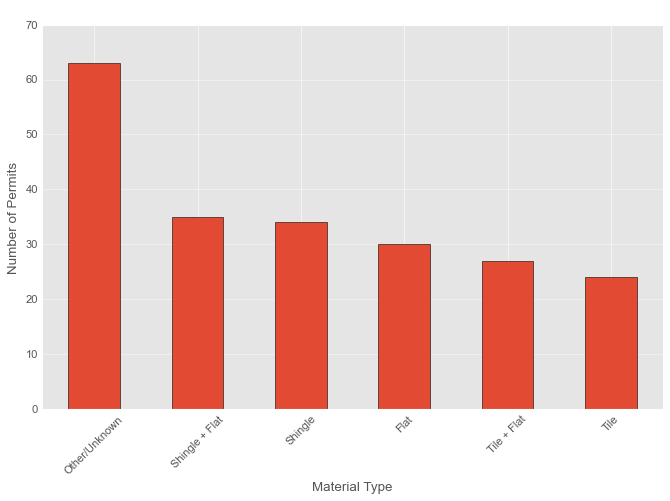

In [59]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Count normalized categories
material_counts = final_df["Roof_Material"].value_counts()

# Plot
plt.figure(figsize=(10,6))
material_counts.plot(kind="bar", edgecolor="black")
plt.title("Distribution of Roofing Materials in Permits")
plt.xlabel("Material Type")
plt.ylabel("Number of Permits")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.75)
plt.show()


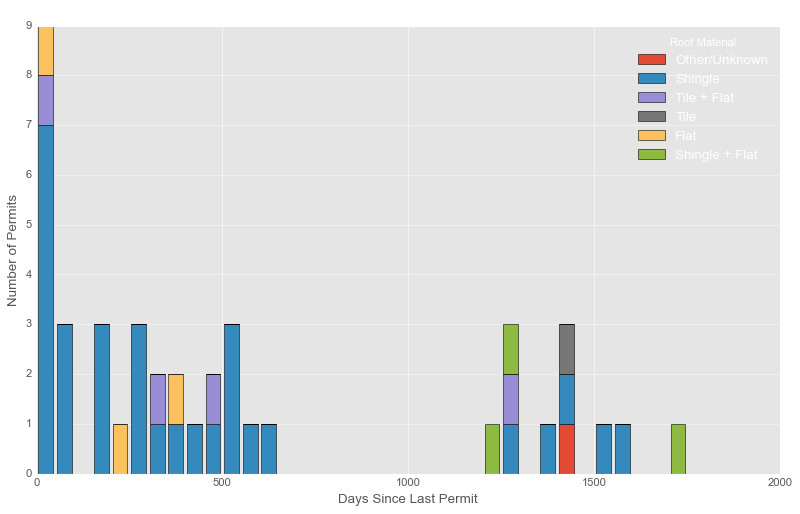

In [62]:
# Filter out NaN and 0 values
data = final_df[
    final_df["Time Since Last Permit"].notna() &
    (final_df["Time Since Last Permit"] != 0)
]

# Prepare the data grouped by roof material
grouped = [
    group["Time Since Last Permit"].values
    for _, group in data.groupby("Roof_Material")
]

labels = data["Roof_Material"].unique()

# Plot stacked histogram
plt.figure(figsize=(12, 7))
plt.hist(grouped, bins=np.arange(0, 2000, 50), stacked=True, label=labels, edgecolor="black")

plt.title("Stacked Distribution of Time Since Last Permit by Roof Material")
plt.xlabel("Days Since Last Permit")
plt.ylabel("Number of Permits")
plt.legend(title="Roof Material")
plt.grid(axis="y", alpha=0.75)
plt.show()

In [68]:
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

cal = fetch_california_housing()

cal

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 